<a href="https://colab.research.google.com/github/SagarEGme/AI-ML/blob/main/implementing_NN_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [82]:
#Load dataset
df_train = pd.read_csv('/content/sample_data/mnist_train.csv')
df_test = pd.read_csv('/content/sample_data/mnist_test.csv')
df_train.shape, df_test.shape
df_train.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [81]:
df_train = np.array(df_train)
m,n = df_train.shape
np.random.shuffle(df_train)
df_train[12]

array([  8,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11,  51,
       113, 193, 193,  51,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [78]:
#Seperating data points into validation and training data
data_dev = df_train[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]
X_dev = X_dev/255

data_train = df_train[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train/255


In [52]:
#Activation functions

def sigmoid(z):
  return 1/(1+np.exp(-z))

def sigmoid_derivative(z):
  s = sigmoid(z)
  return s * (1-s)

def relu(z):
  return np.maximum(0,z)

def relu_derivative(z):
  return (z>0).astype(float)

In [53]:
#initializing parameters
def initialize_parameters():
  w1 = np.random.rand(64,784) - 0.5 # we have 784 input layer and 64 first hidden layer
  b1 = np.random.rand(64,1) - 0.5
  w2 = np.random.rand(32,64) - 0.5
  b2 = np.random.rand(32,1) - 0.5
  w3 = np.random.rand(10,32) - 0.5
  b3 = np.random.rand(10,1) - 0.5
  return w1,b1,w2,b2,w3,b3


In [66]:
#Forward propagation
def softmax(x):
  a = np.exp(x)/sum(np.exp(x))
  return a

def forward_propagation(w1,b1,w2,b2,w3,b3,x):
  z1 = w1.dot(x) + b1
  a1 = relu(z1)
  z2 = w2.dot(a1) + b2
  a2 = relu(z2)
  z3 = w3.dot(a2) + b3
  a3 = softmax(z3)
  return z1,a1,z2,a2,z3,a3

In [67]:
#Encoding
def one_hot(y):
  one_hot_y = np.zeros((y.size,y.max() + 1)) # y.size gives no. of rows of y and y_max gives max value out of all y ie. 9
  one_hot_y[np.arange(y.size),y] = 1 # np.arange takes start,end,step to create an array of evenly distribued numbers and y is the o/p since y's dim is [70000,1]
  one_hot_y = one_hot_y.T
  return one_hot_y

In [68]:
#Backward Propagation
def backward_prop(Z1, A1, Z2, A2, Z3, A3, W1, W2, W3, X, Y):
  one_hot_Y = one_hot(Y)      # Convert labels to one-hot encoding
  dZ3 = A3 - one_hot_Y        # Compute the gradient for the output layer
  dW3 = 1 / m * dZ3.dot(A2.T) # Gradient for weights of output layer
  db3 = 1 / m * np.sum(dZ3)   # Gradient for biases of output layer

  # Backpropagate through the second layer
  dZ2 = W3.T.dot(dZ3) * relu_derivative(Z2)
  dW2 = 1 / m * dZ2.dot(A1.T)   # Gradient for weights of second layer
  db2 = 1 / m * np.sum(dZ2)     # Gradient for biases of second layer

  # Backpropagate through the first layer
  dZ1 = W2.T.dot(dZ2) * relu_derivative(Z1)
  dW1 = 1 / m * dZ1.dot(X.T)     # Gradient for weights of first layer
  db1 = 1 / m * np.sum(dZ1)      # Gradient for biases of first layer

  return dW1, db1, dW2, db2, dW3, db3


In [69]:
def update_params(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, alpha):
    """Updates the parameters using gradient descent."""
    W1 = W1 - alpha * dW1  # Update weights of the first layer
    b1 = b1 - alpha * db1   # Update biases of the first layer
    W2 = W2 - alpha * dW2   # Update weights of the second layer
    b2 = b2 - alpha * db2   # Update biases of the second layer
    W3 = W3 - alpha * dW3   # Update weights of the output layer
    b3 = b3 - alpha * db3   # Update biases of the output layer
    return W1, b1, W2, b2, W3, b3

In [70]:
def get_predictions(A3):
    return np.argmax(A3, 0) # argmax gives the index of the maximum value


def get_accuracy(predictions, Y):
    print(predictions, Y)    # Optional: Print predictions and true labels for inspection
    return np.sum(predictions == Y) / Y.size


def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2, W3, b3 = initialize_parameters()
    for i in range(1, iterations+1):
        # Forward propagation
        Z1, A1, Z2, A2, Z3, A3 = forward_propagation(W1, b1, W2, b2, W3, b3, X)

        # Backward propagation
        dW1, db1, dW2, db2, dW3, db3 = backward_prop(Z1, A1, Z2, A2, Z3, A3, W1, W2, W3, X, Y)

        # Update parameters
        W1, b1, W2, b2, W3, b3 = update_params(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, alpha)

        # Print the progress every 50 iterations
        if i % 50 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A3)
            print("Accuracy: ", get_accuracy(predictions, Y))
    return W1, b1, W2, b2, W3, b3

In [71]:
# Training the neural network on the training set
W1, b1, W2, b2, W3, b3 = gradient_descent(X_train, Y_train, 0.2, 500)

Iteration:  50
[1 7 3 ... 6 0 3] [1 7 3 ... 6 0 3]
Accuracy:  0.7640677966101694
Iteration:  100
[1 7 3 ... 6 0 3] [1 7 3 ... 6 0 3]
Accuracy:  0.832864406779661
Iteration:  150
[1 7 3 ... 6 0 3] [1 7 3 ... 6 0 3]
Accuracy:  0.8619152542372881
Iteration:  200
[1 7 3 ... 6 0 3] [1 7 3 ... 6 0 3]
Accuracy:  0.88
Iteration:  250
[1 7 3 ... 6 0 3] [1 7 3 ... 6 0 3]
Accuracy:  0.892593220338983
Iteration:  300
[1 7 3 ... 6 0 3] [1 7 3 ... 6 0 3]
Accuracy:  0.9010508474576271
Iteration:  350
[1 7 3 ... 6 0 3] [1 7 3 ... 6 0 3]
Accuracy:  0.9079322033898305
Iteration:  400
[1 7 3 ... 6 0 3] [1 7 3 ... 6 0 3]
Accuracy:  0.9133728813559322
Iteration:  450
[1 7 3 ... 6 0 3] [1 7 3 ... 6 0 3]
Accuracy:  0.9178305084745763
Iteration:  500
[1 7 3 ... 6 0 3] [1 7 3 ... 6 0 3]
Accuracy:  0.9216440677966101


In [73]:
def make_predictions(X, W1, b1, W2, b2, W3, b3):
  """Generates predictions for the input data using the trained network."""
  _, _, _, _, _, A3 = forward_propagation(W1, b1, W2, b2, W3, b3, X)
  predictions = get_predictions(A3)
  return predictions

In [74]:
def test_prediction(index, W1, b1, W2, b2, W3, b3):
      current_image = X_train[:, index, None]  # Get the current image (column vector)
      prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2, W3, b3)  # Get prediction for the current image
      label = Y_train[index]  # Get the true label for the current image
      print("Prediction: ", prediction)  # Print the predicted class
      print("Label: ", label)  # Print the true label

      # Reshape the image for displaying and scale back to 0-255
      current_image = current_image.reshape((28, 28)) * 255
      plt.gray()  # Set the colormap to gray
      plt.imshow(current_image, interpolation='nearest')  # Display the image
      plt.show()  # Show the plot

Prediction:  [7]
Label:  7


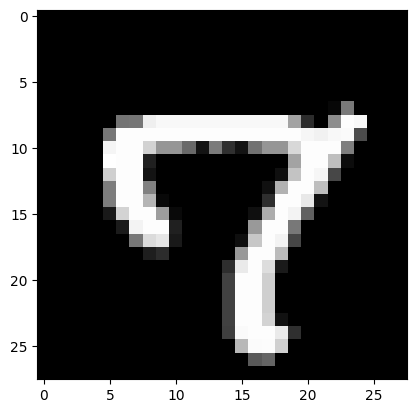

Prediction:  [2]
Label:  8


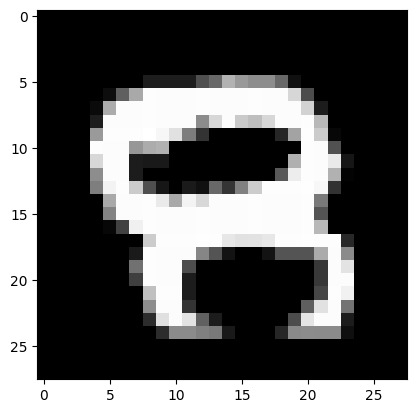

Prediction:  [7]
Label:  7


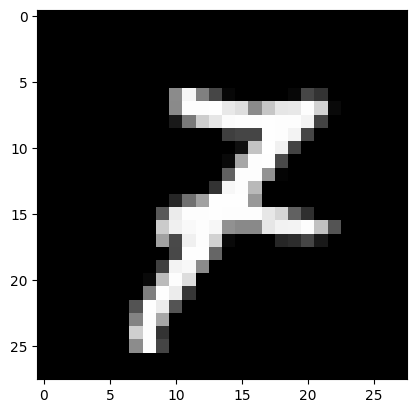

Prediction:  [8]
Label:  8


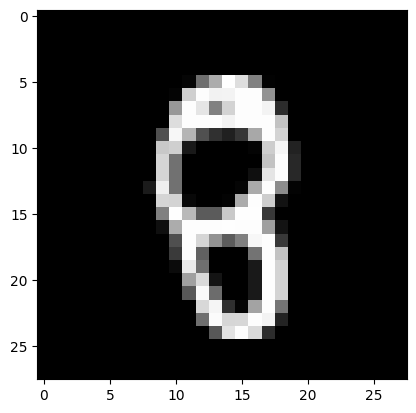

Prediction:  [2]
Label:  2


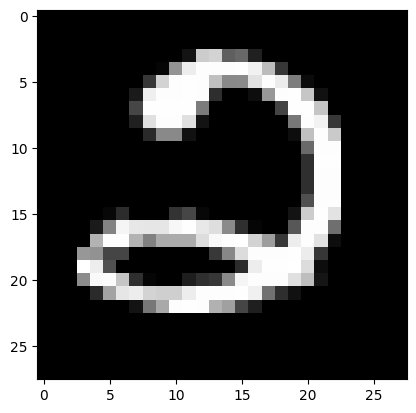

Prediction:  [4]
Label:  4


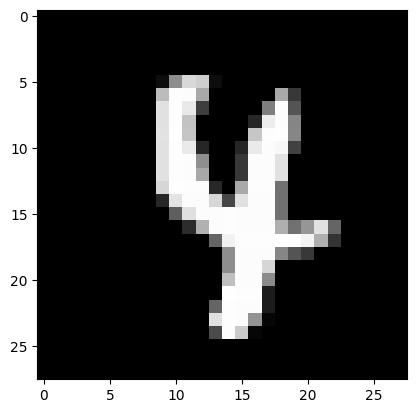

Prediction:  [5]
Label:  5


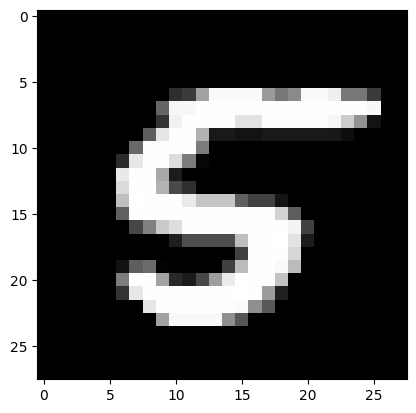

Prediction:  [4]
Label:  4


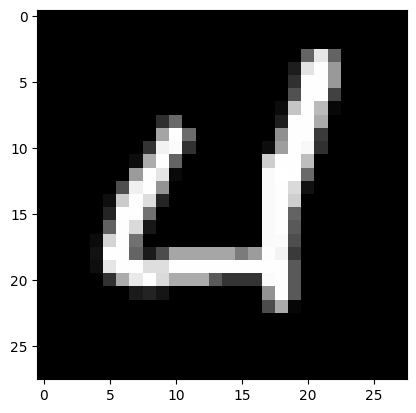

Prediction:  [0]
Label:  0


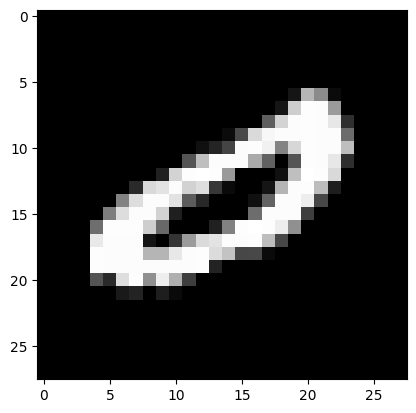

Prediction:  [4]
Label:  4


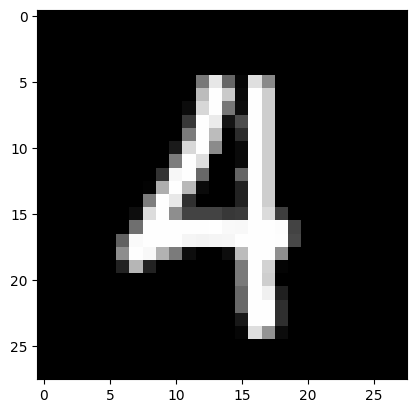

In [75]:
indexes = [1,50,100,150,200,250,300,350,400,450]
for i in indexes:
  test_prediction(i, W1, b1, W2, b2, W3, b3)

In [76]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2, W3, b3)
get_accuracy(dev_predictions, Y_dev)

[0 0 3 2 9 7 3 9 0 5 0 6 2 2 0 6 7 6 0 7 2 5 8 5 8 4 5 8 1 2 6 1 7 1 1 7 9
 1 7 7 4 6 7 3 9 6 9 4 3 6 4 9 7 2 6 4 0 8 3 8 8 7 8 1 6 5 8 6 8 5 2 0 6 6
 9 3 5 5 1 6 1 0 0 5 3 7 6 8 1 1 9 2 5 3 4 6 0 0 9 1 9 2 7 1 8 0 4 6 5 6 9
 1 0 7 4 6 0 8 0 2 1 8 7 2 3 2 0 5 5 8 2 1 4 1 7 9 4 1 3 9 1 4 5 9 6 9 1 9
 7 2 1 8 0 2 7 6 9 4 0 4 2 3 6 5 3 5 7 3 7 2 1 3 9 2 8 9 6 0 5 0 5 0 3 3 2
 2 4 8 6 2 2 2 0 6 2 0 7 7 1 1 4 6 9 5 3 0 8 3 4 0 5 8 9 0 8 9 7 8 2 2 0 1
 7 1 4 1 2 0 4 8 6 6 7 9 5 8 4 8 4 7 7 4 5 2 4 2 2 9 3 9 0 8 5 9 0 4 2 2 8
 0 5 1 7 4 0 2 5 2 2 0 5 2 8 9 2 9 9 7 1 0 1 6 1 2 1 3 5 5 5 9 0 0 5 2 8 2
 7 9 7 9 5 4 5 5 2 9 8 5 1 4 9 4 5 3 1 3 7 3 5 6 4 9 4 3 1 4 7 3 4 7 1 2 1
 5 0 6 4 7 9 5 7 5 1 9 8 7 5 5 0 2 7 8 3 5 7 0 3 7 9 2 7 9 4 0 4 5 3 3 2 9
 6 4 0 2 1 0 9 8 1 2 0 9 9 3 8 2 3 1 7 0 8 6 5 9 6 2 0 9 0 2 6 1 6 0 2 6 0
 3 8 3 2 8 9 4 4 9 6 7 7 0 3 0 0 5 4 7 7 3 0 6 3 2 3 3 4 0 5 9 5 1 0 9 3 8
 4 8 8 1 6 2 5 5 1 7 9 4 7 5 2 0 8 9 2 4 1 4 3 7 7 1 7 1 2 8 6 7 1 8 7 1 2
 6 1 5 9 5 1 4 9 3 1 1 7 

np.float64(0.93)

In [77]:
#Testing on unseen data

# Converting the test data to a NumPy array
test_data = np.array(df_test)

# Getting the number of samples (m_test) and features (n_test) from the test dataset
m_test, n_test = test_data.shape

# Preparing the test data
test_data_dev = test_data.T  # Transposing the test data for easier indexing
Y_test = test_data_dev[0]    # Labels for the test set
X_test = test_data_dev[1:n_test]  # Features for the test set
X_test = X_test / 255         # Normalizing the test input data (values between 0 and 1)

# Making predictions on the test set and calculating accuracy
test_data_predictions = make_predictions(X_test, W1, b1, W2, b2, W3, b3)  # Get predictions for the test set
test_accuracy = get_accuracy(test_data_predictions, Y_test)  # Calculate accuracy for the test set
print("Test Set Accuracy: ", test_accuracy)  # Print the accuracy

[7 2 1 ... 4 5 6] [7 2 1 ... 4 5 6]
Test Set Accuracy:  0.9182
